# TI IWR6843 Fall Detection — Representation 3: Native 3D Point Set (PointNet++)

Trains PyTorch **PointNet / PointNet++** on unordered 3D point matrix (5 channels: x, y, z, v, time).

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

sns.set_theme(style="whitegrid")
torch.manual_seed(42)

preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../../datasets/preprocessed")

X_rep3 = np.load(preproc_dir / "X_rep3_pointset_ti.npy")
y_rep3 = np.load(preproc_dir / "y_rep3_pointset_ti.npy")

print(f"Loaded Representation 3 Point Set Tensor: {X_rep3.shape}")
print(f"Labels: {np.bincount(y_rep3.astype(int))} (0 = ADL, 1 = Fall)")

Loaded Representation 3 Point Set Tensor: (728, 5, 320)
Labels: [364 364] (0 = ADL, 1 = Fall)


In [2]:
class PointNetFallDetector(nn.Module):
    def __init__(self, in_channels=5, num_classes=2):
        super(PointNetFallDetector, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 256, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.4)
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        global_feat = torch.max(x, 2, keepdim=True)[0].view(x.size(0), -1)
        out = self.relu(self.fc1(self.dropout(global_feat)))
        return self.fc2(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PointNetFallDetector().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [3]:
# Train/Test Split & Best Model Checkpointing
X_tr, X_te, y_tr, y_te = train_test_split(X_rep3, y_rep3, test_size=0.2, random_state=42, stratify=y_rep3)
tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
te_ds = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

# Best Model Checkpoint Path
models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "pointnet_rep3_pointset_ti.pth"

epochs = 15
best_val_loss = float('inf')

for ep in range(epochs):
    model.train()
    tot_loss, corr, tot = 0.0, 0, 0
    for bx, by in tr_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        tot_loss += loss.item() * bx.size(0)
        corr += (out.argmax(1) == by).sum().item()
        tot += by.size(0)
    train_loss = tot_loss / tot
    train_acc = corr / tot

   # Validation step to track best model
    model.eval()
    val_loss, val_corr, val_tot = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in te_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            v_loss = criterion(out, by)
            val_loss += v_loss.item() * bx.size(0)
            val_corr += (out.argmax(1) == by).sum().item()
            val_tot += by.size(0)
    val_loss /= val_tot
    val_acc = val_corr / val_tot

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " [BEST SAVED]"
    else:
        saved_flag = ""

    if (ep + 1) % 5 == 0 or ep == 0 or saved_flag:
        print(f"Epoch {ep+1:02d}/{epochs} - Tr Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%{saved_flag}")

# Reload best model weights for evaluation
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model checkpoint from: {best_model_path} (Best Val Loss: {best_val_loss:.4f})")

Epoch 01/15 - Tr Loss: 0.6306 Acc: 65.64% | Val Loss: 0.5999 Acc: 83.56% [BEST SAVED]


Epoch 02/15 - Tr Loss: 0.4264 Acc: 81.79% | Val Loss: 0.3456 Acc: 89.04% [BEST SAVED]


Epoch 04/15 - Tr Loss: 0.3412 Acc: 84.54% | Val Loss: 0.2128 Acc: 93.15% [BEST SAVED]


Epoch 05/15 - Tr Loss: 0.2928 Acc: 88.49% | Val Loss: 0.1956 Acc: 93.15% [BEST SAVED]


Epoch 07/15 - Tr Loss: 0.2362 Acc: 89.00% | Val Loss: 0.1007 Acc: 96.58% [BEST SAVED]


Epoch 08/15 - Tr Loss: 0.2115 Acc: 91.75% | Val Loss: 0.0840 Acc: 97.95% [BEST SAVED]


Epoch 10/15 - Tr Loss: 0.1180 Acc: 95.70% | Val Loss: 0.0560 Acc: 98.63% [BEST SAVED]


Epoch 12/15 - Tr Loss: 0.1291 Acc: 94.85% | Val Loss: 0.0519 Acc: 98.63% [BEST SAVED]


Epoch 13/15 - Tr Loss: 0.0859 Acc: 96.39% | Val Loss: 0.0398 Acc: 99.32% [BEST SAVED]


Epoch 15/15 - Tr Loss: 0.0678 Acc: 97.25% | Val Loss: 0.0243 Acc: 99.32% [BEST SAVED]

Loaded best model checkpoint from: ..\..\models\pointnet_rep3_pointset_ti.pth (Best Val Loss: 0.0243)


--- Representation 3 (PointSet PointNet) Test Results ---
Test Accuracy: 99.32%
ROC-AUC Score: 1.0000

Classification Report:
                  precision    recall  f1-score   support

 ADL (Non-Fall)       1.00      0.99      0.99        73
           Fall       0.99      1.00      0.99        73

       accuracy                           0.99       146
      macro avg       0.99      0.99      0.99       146
   weighted avg       0.99      0.99      0.99       146



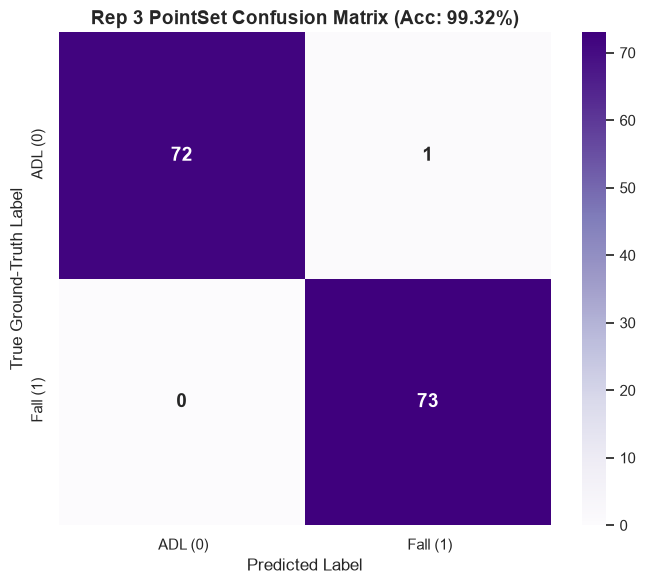

In [4]:
# Evaluate on Test Set
model.eval()
preds_list, probs_list, targets_list = [], [], []
with torch.no_grad():
    for bx, by in te_loader:
        bx = bx.to(device)
        out = model(bx)
        prob = torch.softmax(out, dim=1)[:, 1]
        preds_list.extend(out.argmax(dim=1).cpu().numpy())
        probs_list.extend(prob.cpu().numpy())
        targets_list.extend(by.numpy())

targets_arr = np.array(targets_list)
preds_arr = np.array(preds_list)
probs_arr = np.array(probs_list)

acc = accuracy_score(targets_arr, preds_arr)
auc = roc_auc_score(targets_arr, probs_arr)
cm = confusion_matrix(targets_arr, preds_arr)

print(f"--- Representation 3 (PointSet PointNet) Test Results ---")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC-AUC Score: {auc:.4f}")
print("\nClassification Report:\n", classification_report(targets_arr, preds_arr, target_names=[" ADL (Non-Fall)", " Fall"]))

# Visual Confusion Matrix Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[" ADL (0)", " Fall (1)"],
            yticklabels=[" ADL (0)", " Fall (1)"],
            annot_kws={"size": 14, "weight": "bold"})
plt.title(f"Rep 3 PointSet Confusion Matrix (Acc: {acc*100:.2f}%)", fontweight="bold", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Ground-Truth Label", fontsize=12)
plt.tight_layout()
plt.show()
